## Import Library

In [610]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency

**Thirza Elysia Chandra - CDCC325D6X1020 melakukan proses dari tahap menentukan pertanyaan bisnis, melakukan Data Wrangling hingga Exploratory Data Analysis**

## Pertanyaan Bisnis

1. Sejauh mana individu dalam dataset ini mematuhi alokasi budget persentase mereka dalam setiap kategori pengeluaran?
2. Kategori pengeluaran apa yang paling sering mengalami kondisi over budget dibandingkan alokasi budget persentase yang telah ditentukan pada setiap periode pengeluaran individu?
3. Berapa persentase individu yang memiliki tingkat tabungan sehat berdasarkan persentase savings terhadap income pada setiap periode pengeluaran?

# Data Wrangling

## Gathering Data

In [611]:
# mengambil data dari file CSV lalu mengubahnya jadi tabel
df = pd.read_csv("urban_budget_allocation_dataset_dirty.csv", delimiter=",")

In [612]:
# menampilkan 5 baris pertama dari isi tabel
df.head()

,Income,HousingExpense,TransportationExpense,FoodExpense,UtilitiesExpense,EntertainmentExpense,Savings,HousingBudget,TransportationBudget,FoodBudget,UtilitiesBudget,EntertainmentBudget,SavingsBudget
0,33925.0,7933.0,2382.0,5321.0,2410.0,2587.0,5023.0,30.920642,9.284378,20.739788,9.393514,10.083411,19.578266
1,NaN,6992.0,2536.0,5694.0,3216.0,1060.0,-6054.0,27.363807,9.924859,22.283970,12.586099,4.148403,23.692862
2,NaN,7655.0,2249.0,5402.0,3555.0,1836.0,1777.0,34.061582,10.007119,24.036665,NaN,8.169440,7.906915
3,28831.0,9429.0,1028.0,6110.0,3377.0,1979.0,NaN,37.591197,4.098393,NaN,13.463302,7.889806,12.598174
4,33537.0,10555.0,1922.0,7197.0,3542.0,2007.0,4703.0,35.270333,6.422509,24.049322,11.835862,6.706543,15.715431


**Insight :**

Dataset yang digunakan berasal dari Kaggle dengan topik Urban Allocation Budget. Dataset ini berisi data pendapatan, pengeluaran, dan tabungan masyarakat urban yang digunakan untuk menganalisis pola pengelolaan keuangan serta efektivitas alokasi anggaran pada berbagai kebutuhan sehari-hari. Dataset tersebut telah dimodifikasi oleh tim capstone agar sesuai dengan kebutuhan analisis. Penyesuaian dilakukan pada struktur, atribut, dan kualitas data sehingga lebih relevan dan mampu mendukung proses eksplorasi serta pengambilan insight secara optimal.

## Assesing Data

In [613]:
# menampilkan jumlah baris dan kolom dari dataset
df.shape

(1050, 13)

In [614]:
# menampilkan nama kolom yang ada dalam dataset
df.columns

Index(['Income', 'HousingExpense', 'TransportationExpense', 'FoodExpense',
       'UtilitiesExpense', 'EntertainmentExpense', 'Savings', 'HousingBudget',
       'TransportationBudget', 'FoodBudget', 'UtilitiesBudget',
       'EntertainmentBudget', 'SavingsBudget'],
      dtype='object')

In [615]:
# memeriksa informasi dari isi dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1050 entries, 0 to 1049
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Income                 969 non-null    object 
 1   HousingExpense         966 non-null    float64
 2   TransportationExpense  968 non-null    float64
 3   FoodExpense            967 non-null    float64
 4   UtilitiesExpense       967 non-null    float64
 5   EntertainmentExpense   965 non-null    float64
 6   Savings                967 non-null    float64
 7   HousingBudget          967 non-null    float64
 8   TransportationBudget   964 non-null    float64
 9   FoodBudget             968 non-null    float64
 10  UtilitiesBudget        968 non-null    float64
 11  EntertainmentBudget    969 non-null    float64
 12  SavingsBudget          964 non-null    float64
dtypes: float64(12), object(1)
memory usage: 106.8+ KB


In [616]:
# memeriksa jumlah missing values dari dataset
df.isna().sum()

,0
Income,81
HousingExpense,84
TransportationExpense,82
FoodExpense,83
UtilitiesExpense,83
EntertainmentExpense,85
Savings,83
HousingBudget,83
TransportationBudget,86
FoodBudget,82


In [617]:
# Mengecek jumlah dan persentase missing values
missing_summary = pd.DataFrame({
    'Jumlah Missing': df.isna().sum(),
    'Persentase Missing': (
        df.isna().sum() / len(df) * 100
    ).round(2).astype(str) + '%'
})

# Tampilkan hanya kolom yang memiliki missing value
missing_summary = missing_summary[
    missing_summary['Jumlah Missing'] > 0
]

print(missing_summary)

                       Jumlah Missing Persentase Missing
Income                             81              7.71%
HousingExpense                     84               8.0%
TransportationExpense              82              7.81%
FoodExpense                        83               7.9%
UtilitiesExpense                   83               7.9%
EntertainmentExpense               85               8.1%
Savings                            83               7.9%
HousingBudget                      83               7.9%
TransportationBudget               86              8.19%
FoodBudget                         82              7.81%
UtilitiesBudget                    82              7.81%
EntertainmentBudget                81              7.71%
SavingsBudget                      86              8.19%


In [618]:
# memeriksa duplikasi data dari dataset
print("Jumlah duplikasi: ",df.duplicated().sum())

Jumlah duplikasi:  46


In [619]:
# menampilkan ringkasan parameter statistik dataset
df.describe()

,HousingExpense,TransportationExpense,FoodExpense,UtilitiesExpense,EntertainmentExpense,Savings,HousingBudget,TransportationBudget,FoodBudget,UtilitiesBudget,EntertainmentBudget,SavingsBudget
count,966.000000,968.000000,967.000000,967.000000,965.000000,967.000000,967.000000,964.000000,968.000000,968.000000,969.000000,964.000000
mean,8783.664596,1992.464876,5967.850052,2983.398139,2002.630052,5327.100827,30.660658,7.737312,22.984952,11.542112,7.740419,19.413111
std,6289.518292,489.726117,966.592874,515.426971,483.963206,3483.372362,6.055722,2.056933,4.049773,2.304947,1.981251,6.718289
min,326.000000,38.000000,2767.000000,1312.000000,608.000000,-10380.000000,1.598039,0.153170,12.075060,5.019569,2.313458,-6.768534
25%,6743.250000,1656.000000,5311.500000,2650.000000,1676.000000,3739.500000,26.839657,6.283824,20.099431,9.993364,6.358445,15.295833
50%,8105.500000,1997.000000,5972.000000,2983.000000,2000.000000,5162.000000,30.920642,7.682783,22.710953,11.418531,7.702396,20.136665
75%,9436.500000,2326.500000,6612.000000,3310.500000,2334.000000,6493.000000,34.662747,9.116888,25.625015,13.053613,9.025059,23.791402
max,56238.000000,3384.000000,8914.000000,4688.000000,3642.000000,25802.500000,49.562440,14.337552,39.647646,23.381295,15.615724,38.507037


In [620]:
# mendeteksi dan menghitung jumlah outlier di tiap kolom numerik menggunakan metode IQR
cols = df.select_dtypes(include=['int64', 'float64']).columns

outliers = {}

total_data = len(df)

for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    outlier_data = df[
        (df[col] < Q1 - 1.5 * IQR) |
        (df[col] > Q3 + 1.5 * IQR)
    ]

    outliers[col] = outlier_data

for col in outliers:
    jumlah_outlier = len(outliers[col])
    persen_outlier = (jumlah_outlier / total_data) * 100

    print(f"{col} : {jumlah_outlier} outlier ({persen_outlier:.2f}%)")

HousingExpense : 22 outlier (2.10%)
TransportationExpense : 4 outlier (0.38%)
FoodExpense : 10 outlier (0.95%)
UtilitiesExpense : 16 outlier (1.52%)
EntertainmentExpense : 5 outlier (0.48%)
Savings : 33 outlier (3.14%)
HousingBudget : 11 outlier (1.05%)
TransportationBudget : 7 outlier (0.67%)
FoodBudget : 8 outlier (0.76%)
UtilitiesBudget : 12 outlier (1.14%)
EntertainmentBudget : 11 outlier (1.05%)
SavingsBudget : 14 outlier (1.33%)


In [621]:
# menampilkan ringkasan parameter statistik dataset
df.describe()

,HousingExpense,TransportationExpense,FoodExpense,UtilitiesExpense,EntertainmentExpense,Savings,HousingBudget,TransportationBudget,FoodBudget,UtilitiesBudget,EntertainmentBudget,SavingsBudget
count,966.000000,968.000000,967.000000,967.000000,965.000000,967.000000,967.000000,964.000000,968.000000,968.000000,969.000000,964.000000
mean,8783.664596,1992.464876,5967.850052,2983.398139,2002.630052,5327.100827,30.660658,7.737312,22.984952,11.542112,7.740419,19.413111
std,6289.518292,489.726117,966.592874,515.426971,483.963206,3483.372362,6.055722,2.056933,4.049773,2.304947,1.981251,6.718289
min,326.000000,38.000000,2767.000000,1312.000000,608.000000,-10380.000000,1.598039,0.153170,12.075060,5.019569,2.313458,-6.768534
25%,6743.250000,1656.000000,5311.500000,2650.000000,1676.000000,3739.500000,26.839657,6.283824,20.099431,9.993364,6.358445,15.295833
50%,8105.500000,1997.000000,5972.000000,2983.000000,2000.000000,5162.000000,30.920642,7.682783,22.710953,11.418531,7.702396,20.136665
75%,9436.500000,2326.500000,6612.000000,3310.500000,2334.000000,6493.000000,34.662747,9.116888,25.625015,13.053613,9.025059,23.791402
max,56238.000000,3384.000000,8914.000000,4688.000000,3642.000000,25802.500000,49.562440,14.337552,39.647646,23.381295,15.615724,38.507037


**Insight :**

1. Dataset terdiri dari 13 kolom dan 1050 baris data terkait pengelolaan anggaran masyarakat urban.
2. Ditemukan missing value pada setiap kolom sehingga diperlukan proses data cleaning.
3. Terdapat ketidaksesuaian tipe data pada beberapa kolom yang perlu disesuaikan agar analisis lebih akurat.
4. Kolom untuk kategori budget (HousingBudget, TransportationBudget, FoodBudget, UtilitiesBudget, EntertainmentBudget, dan SavingsBudget) berbentuk persentase sehingga menggunakan tipe data float.
5. Dataset memiliki 46 data duplikat yang perlu dihapus untuk menjaga kualitas data.
6. Terdapat outlier pada beberapa kolom, namun tidak seluruh nilai outlier bersifat merusak karena sebagian masih merepresentasikan kondisi finansial yang realistis dalam dataset.

## Cleaning Data

In [622]:
# menghapus duplikasi data pada tabel
df.drop_duplicates(inplace=True)

In [623]:
# membersihkan kolom Income dengan menghapus koma, teks USD, dan spasi, dan mengubah data menjadi tipe numerik
cols = [
    'Income',
]

for col in cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(',', '', regex=False)
        .str.replace('USD', '', regex=False)
        .str.strip()
    )

    df[col] = pd.to_numeric(df[col], errors='coerce')

In [624]:
# memeriksa duplikasi data dari dataset
print("Jumlah duplikasi: ",df.duplicated().sum())

Jumlah duplikasi:  2


In [625]:
# mengisi nilai kosong (NaN) dengan nilai median dari masing-masing kolom numerik
df = df.fillna(df.median(numeric_only=True))

In [626]:
# memeriksa jumlah missing values dari dataset setelah mengganti dengan nilai median
df.isna().sum()

,0
Income,0
HousingExpense,0
TransportationExpense,0
FoodExpense,0
UtilitiesExpense,0
EntertainmentExpense,0
Savings,0
HousingBudget,0
TransportationBudget,0
FoodBudget,0


In [627]:
# menampilkan ringkasan parameter statistik dataset
df.describe()

,Income,HousingExpense,TransportationExpense,FoodExpense,UtilitiesExpense,EntertainmentExpense,Savings,HousingBudget,TransportationBudget,FoodBudget,UtilitiesBudget,EntertainmentBudget,SavingsBudget
count,1004.000000,1004.000000,1004.000000,1004.000000,1004.000000,1004.000000,1004.000000,1004.000000,1004.000000,1004.000000,1004.000000,1004.000000,1004.000000
mean,31940.637450,8744.062749,1994.131474,5969.337649,2991.399402,2002.210159,5309.080179,30.644108,7.735874,22.991807,11.574634,7.740363,19.437832
std,15404.268267,6162.355123,468.081580,931.595308,492.171505,466.248782,3400.681678,5.867531,1.971030,3.898258,2.219471,1.907504,6.502539
min,11558.000000,326.000000,38.000000,2767.000000,1312.000000,608.000000,-10380.000000,1.598039,0.153170,12.075060,5.019569,2.313458,-6.768534
25%,27041.500000,6888.250000,1704.000000,5347.500000,2688.000000,1697.000000,3822.500000,27.286672,6.381017,20.292446,10.182324,6.535369,15.769713
50%,30161.500000,8086.000000,1999.000000,5969.500000,2990.000000,2004.000000,5162.000000,30.913153,7.686700,22.743472,11.489830,7.682212,20.143710
75%,33518.000000,9285.500000,2291.500000,6549.250000,3287.250000,2293.250000,6394.500000,34.223033,8.995563,25.526105,12.904349,8.883745,23.485244
max,150330.000000,56238.000000,3384.000000,8914.000000,4688.000000,3642.000000,25802.500000,49.562440,14.337552,39.647646,23.381295,15.615724,38.507037


In [628]:
# menghapus duplikasi data pada tabel
df.drop_duplicates(inplace=True)

In [629]:
# memeriksa jumlah duplikasi dari tabel setelah menghapus duplikasi data
print("Jumlah duplikasi: ",df.duplicated().sum())

Jumlah duplikasi:  0


In [630]:
# menampilkan ringkasan parameter statistik dataset
df.describe()

,Income,HousingExpense,TransportationExpense,FoodExpense,UtilitiesExpense,EntertainmentExpense,Savings,HousingBudget,TransportationBudget,FoodBudget,UtilitiesBudget,EntertainmentBudget,SavingsBudget
count,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000
mean,31941.341317,8748.156687,1993.965070,5969.527944,2990.804391,2001.835329,5309.159182,30.651353,7.733841,22.989069,11.570428,7.737792,19.432970
std,15419.387912,6167.511242,467.986797,932.180931,492.453867,466.124391,3404.027112,5.868558,1.969264,3.901309,2.219675,1.907175,6.508047
min,11558.000000,326.000000,38.000000,2767.000000,1312.000000,608.000000,-10380.000000,1.598039,0.153170,12.075060,5.019569,2.313458,-6.768534
25%,27038.500000,6891.750000,1704.250000,5349.250000,2688.000000,1697.000000,3821.500000,27.290755,6.384783,20.283623,10.181820,6.520957,15.765316
50%,30161.500000,8086.000000,1999.000000,5969.500000,2990.000000,2004.000000,5162.000000,30.913153,7.686700,22.743472,11.489830,7.682212,20.143710
75%,33511.250000,9286.500000,2290.750000,6549.750000,3286.750000,2293.000000,6395.500000,34.224457,8.994728,25.524574,12.899566,8.878249,23.509343
max,150330.000000,56238.000000,3384.000000,8914.000000,4688.000000,3642.000000,25802.500000,49.562440,14.337552,39.647646,23.381295,15.615724,38.507037


In [631]:
# mengubah tipe data pada beberapa kolom menjadi integer
cols = [
    'Income',
    'HousingExpense',
    'TransportationExpense',
    'FoodExpense',
    'UtilitiesExpense',
    'EntertainmentExpense',
    'Savings'
]

df[cols] = df[cols].astype(int)

In [632]:
# menampilkan tipe data dari setiap kolom pada dataset
df.dtypes

,0
Income,int64
HousingExpense,int64
TransportationExpense,int64
FoodExpense,int64
UtilitiesExpense,int64
EntertainmentExpense,int64
Savings,int64
HousingBudget,float64
TransportationBudget,float64
FoodBudget,float64


In [633]:
# mendeteksi dan menghitung jumlah outlier di tiap kolom numerik menggunakan metode IQR
cols = df.select_dtypes(include=['int64', 'float64']).columns

outliers = {}

total_data = len(df)

for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    outlier_data = df[
        (df[col] < Q1 - 1.5 * IQR) |
        (df[col] > Q3 + 1.5 * IQR)
    ]

    outliers[col] = outlier_data

for col in outliers:
    jumlah_outlier = len(outliers[col])
    persen_outlier = (jumlah_outlier / total_data) * 100

    print(f"{col} : {jumlah_outlier} outlier ({persen_outlier:.2f}%)")

Income : 30 outlier (2.99%)
HousingExpense : 34 outlier (3.39%)
TransportationExpense : 10 outlier (1.00%)
FoodExpense : 14 outlier (1.40%)
UtilitiesExpense : 26 outlier (2.59%)
EntertainmentExpense : 10 outlier (1.00%)
Savings : 36 outlier (3.59%)
HousingBudget : 24 outlier (2.40%)
TransportationBudget : 11 outlier (1.10%)
FoodBudget : 10 outlier (1.00%)
UtilitiesBudget : 23 outlier (2.30%)
EntertainmentBudget : 23 outlier (2.30%)
SavingsBudget : 26 outlier (2.59%)


In [634]:
# menghitung batas atas dan bawah kolom Income dan melakukan IQR capping
Q1 = df['Savings'].quantile(0.25)
Q3 = df['Savings'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower :", lower)
print("Upper :", upper)

df['Savings'] = df['Savings'].clip(lower, upper)

df['Savings'].describe()

Lower : -39.5
Upper : 10256.5


,Savings
count,1002.000000
mean,5142.045908
std,2067.477881
min,-39.500000
25%,3821.500000
50%,5162.000000
75%,6395.500000
max,10256.500000


In [635]:
# mengganti nilai negatif pada kolom Savings dan SavingsBudget dengan nilai median dari data yang valid
cols = ['Savings', 'SavingsBudget']

for col in cols:
    median_value = df.loc[df[col] >= 0, col].median()

    df.loc[df[col] < 0, col] = median_value

In [636]:
# menampilkan ringkasan parameter statistik dataset
df.describe()

,Income,HousingExpense,TransportationExpense,FoodExpense,UtilitiesExpense,EntertainmentExpense,Savings,HousingBudget,TransportationBudget,FoodBudget,UtilitiesBudget,EntertainmentBudget,SavingsBudget
count,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000
mean,31941.302395,8748.156687,1993.965070,5969.488024,2990.804391,2001.835329,5214.721557,30.651353,7.733841,22.989069,11.570428,7.737792,19.578182
std,15419.392410,6167.511242,467.986797,932.180942,492.453867,466.124391,1973.241238,5.868558,1.969264,3.901309,2.219675,1.907175,6.244395
min,11558.000000,326.000000,38.000000,2767.000000,1312.000000,608.000000,58.000000,1.598039,0.153170,12.075060,5.019569,2.313458,0.253530
25%,27038.500000,6891.750000,1704.250000,5349.250000,2688.000000,1697.000000,3855.500000,27.290755,6.384783,20.283623,10.181820,6.520957,15.810468
50%,30161.000000,8086.000000,1999.000000,5969.000000,2990.000000,2004.000000,5162.000000,30.913153,7.686700,22.743472,11.489830,7.682212,20.143710
75%,33511.250000,9286.500000,2290.750000,6549.750000,3286.750000,2293.000000,6395.500000,34.224457,8.994728,25.524574,12.899566,8.878249,23.509343
max,150330.000000,56238.000000,3384.000000,8914.000000,4688.000000,3642.000000,10256.500000,49.562440,14.337552,39.647646,23.381295,15.615724,38.507037


In [637]:
# menghitung batas atas dan bawah kolom Income dan melakukan IQR capping
Q1 = df['Income'].quantile(0.25)
Q3 = df['Income'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower :", lower)
print("Upper :", upper)

df['Income'] = df['Income'].clip(lower, upper)

df['Income'].describe()

Lower : 17329.375
Upper : 43220.375


,Income
count,1002.000000
mean,30350.642964
std,5122.292931
min,17329.375000
25%,27038.500000
50%,30161.000000
75%,33511.250000
max,43220.375000


In [638]:
# menghitung batas atas dan bawah kolom HousingExpense dan melakukan IQR capping
Q1 = df['HousingExpense'].quantile(0.25)
Q3 = df['HousingExpense'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("HousingExpense :", lower)
print("HousingExpense :", upper)

df['HousingExpense'] = df['HousingExpense'].clip(lower, upper)

df['HousingExpense'].describe()


HousingExpense : 3299.625
HousingExpense : 12878.625


,HousingExpense
count,1002.000000
mean,8101.199850
std,1978.947004
min,3299.625000
25%,6891.750000
50%,8086.000000
75%,9286.500000
max,12878.625000


In [639]:
# menghitung batas atas dan bawah kolom Savings dan melakukan IQR capping
Q1 = df['Savings'].quantile(0.25)
Q3 = df['Savings'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower :", lower)
print("Upper :", upper)

df['Savings'] = df['Savings'].clip(lower, upper)

df['Savings'].describe()

Lower : 45.5
Upper : 10205.5


,Savings
count,1002.000000
mean,5213.557385
std,1970.276282
min,58.000000
25%,3855.500000
50%,5162.000000
75%,6395.500000
max,10205.500000


In [640]:
# mendeteksi dan menghitung jumlah outlier di tiap kolom numerik menggunakan metode IQR setelah mengatasi outlier pada 3 kolom
cols = df.select_dtypes(include=['int64', 'float64']).columns

outliers = {}

for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    outliers[col] = df[
        (df[col] < Q1 - 1.5 * IQR) |
        (df[col] > Q3 + 1.5 * IQR)
    ]

for col in outliers:
    print(col, ":", len(outliers[col]))

Income : 0
HousingExpense : 0
TransportationExpense : 10
FoodExpense : 14
UtilitiesExpense : 26
EntertainmentExpense : 10
Savings : 0
HousingBudget : 24
TransportationBudget : 11
FoodBudget : 10
UtilitiesBudget : 23
EntertainmentBudget : 23
SavingsBudget : 21


In [641]:
# menampilkan ringkasan parameter statistik dataset
df.describe()

,Income,HousingExpense,TransportationExpense,FoodExpense,UtilitiesExpense,EntertainmentExpense,Savings,HousingBudget,TransportationBudget,FoodBudget,UtilitiesBudget,EntertainmentBudget,SavingsBudget
count,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000
mean,30350.642964,8101.199850,1993.965070,5969.488024,2990.804391,2001.835329,5213.557385,30.651353,7.733841,22.989069,11.570428,7.737792,19.578182
std,5122.292931,1978.947004,467.986797,932.180942,492.453867,466.124391,1970.276282,5.868558,1.969264,3.901309,2.219675,1.907175,6.244395
min,17329.375000,3299.625000,38.000000,2767.000000,1312.000000,608.000000,58.000000,1.598039,0.153170,12.075060,5.019569,2.313458,0.253530
25%,27038.500000,6891.750000,1704.250000,5349.250000,2688.000000,1697.000000,3855.500000,27.290755,6.384783,20.283623,10.181820,6.520957,15.810468
50%,30161.000000,8086.000000,1999.000000,5969.000000,2990.000000,2004.000000,5162.000000,30.913153,7.686700,22.743472,11.489830,7.682212,20.143710
75%,33511.250000,9286.500000,2290.750000,6549.750000,3286.750000,2293.000000,6395.500000,34.224457,8.994728,25.524574,12.899566,8.878249,23.509343
max,43220.375000,12878.625000,3384.000000,8914.000000,4688.000000,3642.000000,10205.500000,49.562440,14.337552,39.647646,23.381295,15.615724,38.507037


In [642]:
# menyimpan dataset hasil cleaning ke file CSV tanpa menyertakan index
df.to_csv("urban_budget_allocation_dataset_clean.csv", index=False)

**Insight :**

1. Missing value ditangani dengan mengganti nilai yang kosong menggunakan median dari masing-masing kolom.
2. Data duplikat berhasil ditangani dengan menghapus seluruh data yang terdeteksi duplikat sehingga dataset menjadi lebih konsisten.
3. Beberapa kolom seperti Income, HousingExpense, TransportationExpense, FoodExpense, UtilitiesExpense, EntertainmentExpense, dan Savings diubah ke tipe data integer agar sesuai dengan representasi nilai numerik.
4. Nilai negatif pada kolom Savings dan SavingsBudget ditangani menggunakan median dari data valid.
5. Outlier pada kolom Income, HousingExpense, dan Savings ditangani menggunakan metode IQR Capping agar nilai ekstrem lebih terkendali.
6. Beberapa outlier tetap dipertahankan karena masih mencerminkan kondisi finansial yang realistis dan tidak terindikasi sebagai kesalahan data, sehingga variasi informasi dalam dataset tetap terjaga.


## Exploratory Data Analysis (EDA)

### Pertanyaan 1

In [643]:
# membuat daftar kolom budget dan pengeluaran yang akan digunakan
budget_cols = [
    'HousingBudget',
    'TransportationBudget',
    'FoodBudget',
    'UtilitiesBudget',
    'EntertainmentBudget',
    'SavingsBudget'
]

expense_cols = [
    'HousingExpense',
    'TransportationExpense',
    'FoodExpense',
    'UtilitiesExpense',
    'EntertainmentExpense',
    'Savings'
]

# mengubah nilai budget dalam bentuk persentase menjadi nominal berdasarkan total Income
for col in budget_cols:
    df[col + 'Nominal'] = df['Income'] * df[col] / 100

In [644]:
# menghitung selisih antara pengeluaran aktual dan budget nominal pada setiap kategori
df['HousingDeviation'] = df['HousingExpense'] - df['HousingBudgetNominal']
df['TransportationDeviation'] = df['TransportationExpense'] - df['TransportationBudgetNominal']
df['FoodDeviation'] = df['FoodExpense'] - df['FoodBudgetNominal']
df['UtilitiesDeviation'] = df['UtilitiesExpense'] - df['UtilitiesBudgetNominal']
df['EntertainmentDeviation'] = df['EntertainmentExpense'] - df['EntertainmentBudgetNominal']
df['SavingsDeviation'] = df['Savings'] - df['SavingsBudgetNominal']

In [645]:
# menghitung total pengeluaran, total budget, dan rasio kepatuhan terhadap budget
df['TotalExpense'] = df[expense_cols].sum(axis=1)

df['TotalBudget'] = (
    df['HousingBudgetNominal'] +
    df['TransportationBudgetNominal'] +
    df['FoodBudgetNominal'] +
    df['UtilitiesBudgetNominal'] +
    df['EntertainmentBudgetNominal'] +
    df['SavingsBudgetNominal']
)

df['BudgetAdherenceRatio'] = df['TotalExpense'] / df['TotalBudget']

In [646]:
# mengelompokkan tingkat kepatuhan budget menggunakan variabel sementara
adherence_category = df['BudgetAdherenceRatio'].apply(
    lambda x: (
        "Under Budget" if x < 0.9
        else "On Track" if 0.9 <= x <= 1.1
        else "Over Budget"
    )
)

In [647]:
# menghitung jumlah
count_summary = adherence_category.value_counts()

# membuat ringkasan budget adherence
budget_summary = pd.DataFrame({
    'Jumlah': adherence_category.value_counts(),
    'Persentase': (
        adherence_category.value_counts(normalize=True) * 100
    ).round(2).astype(str) + '%'
})

print(budget_summary)

                      Jumlah Persentase
BudgetAdherenceRatio                   
Under Budget             581     57.98%
On Track                 292     29.14%
Over Budget              129     12.87%


### Pertanyaan 2

In [648]:
# mengecek apakah pengeluaran pada setiap kategori melebihi budget yang telah ditentukan
df['HousingOverBudget'] = (
    df['HousingExpense'] > df['HousingBudgetNominal']
)

df['TransportationOverBudget'] = (
    df['TransportationExpense'] >
    df['TransportationBudgetNominal']
)

df['FoodOverBudget'] = (
    df['FoodExpense'] > df['FoodBudgetNominal']
)

df['UtilitiesOverBudget'] = (
    df['UtilitiesExpense'] >
    df['UtilitiesBudgetNominal']
)

df['EntertainmentOverBudget'] = (
    df['EntertainmentExpense'] >
    df['EntertainmentBudgetNominal']
)

df['SavingOverBudget'] = (
    df['Savings'] >
    df['SavingsBudgetNominal']
)


In [649]:
# menghitung jumlah kategori yang mengalami over budget
over_budget_counts = {
    'Housing': df['HousingOverBudget'].sum(),
    'Transportation': df['TransportationOverBudget'].sum(),
    'Food': df['FoodOverBudget'].sum(),
    'Utilities': df['UtilitiesOverBudget'].sum(),
    'Entertainment': df['EntertainmentOverBudget'].sum(),
    'Savings' : df['SavingOverBudget'].sum()
}

In [650]:
# mengubah data over budget menjadi DataFrame
result = pd.DataFrame({
    'Category': over_budget_counts.keys(),
    'OverBudgetCount': over_budget_counts.values()
})

In [651]:
# menghitung persentase over budget
result['PersentaseOverBudget'] = (
    result['OverBudgetCount'] / result['OverBudgetCount'].sum()
) * 100

# mengurutkan berdasarkan jumlah over budget tertinggi
result = result.sort_values(
    by='OverBudgetCount',
    ascending=False
)

result['PersentaseOverBudget'] = (
    result['PersentaseOverBudget']
    .round(2)
    .astype(str) + '%'
)

print(result)

         Category  OverBudgetCount PersentaseOverBudget
0         Housing              263               17.42%
5         Savings              254               16.82%
4   Entertainment              254               16.82%
2            Food              249               16.49%
3       Utilities              248               16.42%
1  Transportation              242               16.03%


### Pertanyaan 3

In [652]:
# menghitung persentase tabungan terhadap pendapatan
df['SavingsRate'] = df['Savings'] / df['Income']

In [653]:
# menentukan status tabungan berdasarkan persentase savings terhadap income
df['SavingsStatus'] = np.where(
    df['SavingsRate'] >= 0.2,
    'Healthy Saving',
    'Low Saving'
)

In [654]:
# menghitung jumlah data pada setiap kategori status tabungan
count_summary = df['SavingsStatus'].value_counts()

# menghitung persentase setiap kategori status tabungan
percentage_summary = (
    df['SavingsStatus']
    .value_counts(normalize=True) * 100
).round(2).astype(str) + '%'

# membuat dan menampilkan ringkasan jumlah serta persentase status tabungan
summary = pd.DataFrame({
    'Jumlah Individu': count_summary,
    'Persentase': percentage_summary
})

print(summary)

                Jumlah Individu Persentase
SavingsStatus                             
Low Saving                  677     67.56%
Healthy Saving              325     32.44%


**Insight:**

1. Berdasarkan perhitungan tingkat kepatuhan terhadap anggaran, mayoritas data berada pada kategori under budget sebanyak 581 individu, diikuti kategori on track sebanyak 291 individu, dan over budget sebanyak 129 individu. Hasil ini menunjukkan bahwa sebagian besar individu masih mampu menjaga pengeluaran tetap berada di bawah anggaran yang ditetapkan.

2. Berdasarkan analisis pengeluaran yang melebihi anggaran, kategori HousingExpense menjadi pengeluaran yang paling sering melampaui budget dengan total 263 data. Posisi berikutnya ditempati Savings dan EntertainmentExpense dengan jumlah yang sama, yaitu 254 data, diikuti FoodExpense sebanyak 249 data, UtilitiesExpense sebanyak 248 data, dan TransportationExpense sebanyak 242 data. Hal ini menunjukkan bahwa kebutuhan tempat tinggal menjadi faktor pengeluaran yang paling sulit dikendalikan.

3. Berdasarkan analisis persentase tabungan terhadap pendapatan, mayoritas individu berada pada kategori Low Saving sebanyak 677 individu, sedangkan kategori Healthy Saving berjumlah 325 individu. Hal ini menunjukkan bahwa sebagian besar individu masih memiliki tingkat tabungan yang belum sehat dibandingkan pendapatannya.


**Richard Liestianto - CDCC325D6Y0418 melakukan proses dari tahap Feature Engineering, Visualization & Explanatory Analysis dan A/B Testing**

## Feature Engineering

In [655]:
# menghitung sisa saldo dari pendapatan setelah dikurangi total pengeluaran
df['NetBalance'] = df['Income'] - df['TotalExpense']

In [656]:
# menentukan status keuangan berdasarkan sisa saldo
df['FinancialStatus'] = df['NetBalance'].apply(
    lambda x: 'Surplus' if x > 0 else 'Deficit'
)

In [657]:
# membuat ringkasan jumlah dan persentase untuk setiap kategori status keuangan
status_summary = pd.DataFrame({
    'Jumlah Individu': df['FinancialStatus'].value_counts(),
    'Persentase': (
        df['FinancialStatus']
        .value_counts(normalize=True) * 100
    ).round(2)
})

In [658]:
# mengelompokkan tingkat kondisi keuangan berdasarkan nilai saldo
df['FinancialLevel'] = pd.cut(
    df['NetBalance'],
    bins=[-float('inf'), 0, 1000, float('inf')],
    labels=['Unhealthy', 'At Risk', 'Healthy']
)

In [659]:
# membuat visualisasi persentase status tabungan individu dalam bentuk diagram batang
level_summary = pd.DataFrame({
    'Jumlah Individu': df['FinancialLevel'].value_counts(),
    'Persentase': (
        df['FinancialLevel']
        .value_counts(normalize=True) * 100
    ).round(2)
})

In [660]:
# menghitung jumlah kategori pengeluaran yang mengalami over budget pada setiap data
df['OverBudgetCount'] = (
    df[
        [
            'HousingOverBudget',
            'TransportationOverBudget',
            'FoodOverBudget',
            'UtilitiesOverBudget',
            'EntertainmentOverBudget'
        ]
    ]
    .sum(axis=1)
)

In [661]:
# menghapus kolom sementara yang sudah tidak digunakan
temporary_columns = [
    'HousingBudgetNominal',
    'TransportationBudgetNominal',
    'FoodBudgetNominal',
    'UtilitiesBudgetNominal',
    'EntertainmentBudgetNominal',
    'SavingsBudgetNominal'
]

df.drop(columns=temporary_columns, inplace=True)

In [662]:
# memilih kolom yang akan digunakan lalu menampilkan 5 data pertama
selected_columns = [

    # Original Features
    'Income',
    'HousingExpense',
    'TransportationExpense',
    'FoodExpense',
    'UtilitiesExpense',
    'EntertainmentExpense',
    'Savings',

    # Engineered Features
    'TotalExpense',
    'NetBalance',
    'BudgetAdherenceRatio',
    'OverBudgetCount',
    'FinancialStatus',
    'FinancialLevel',
    'SavingsRate',
    'SavingsStatus'
]

print(df[selected_columns].head())

    Income  HousingExpense  TransportationExpense  FoodExpense  \
0  33925.0          7933.0                   2382         5321   
1  30161.0          6992.0                   2536         5694   
2  30161.0          7655.0                   2249         5402   
3  28831.0          9429.0                   1028         6110   
4  33537.0         10555.0                   1922         7197   

   UtilitiesExpense  EntertainmentExpense  Savings  TotalExpense  NetBalance  \
0              2410                  2587   5023.0       25656.0      8269.0   
1              3216                  1060   5162.0       24660.0      5501.0   
2              3555                  1836   1777.0       22474.0      7687.0   
3              3377                  1979   5162.0       27085.0      1746.0   
4              3542                  2007   4703.0       29926.0      3611.0   

   BudgetAdherenceRatio  OverBudgetCount FinancialStatus FinancialLevel  \
0              0.756256                0       

In [663]:
# memilih kolom akhir yang akan digunakan pada dataset
final_columns = [

    # Original Columns
    'Income',
    'HousingExpense',
    'TransportationExpense',
    'FoodExpense',
    'UtilitiesExpense',
    'EntertainmentExpense',
    'Savings',

    # Engineered Features
    'TotalExpense',
    'NetBalance',

    # Original Columns
    'HousingBudget',
    'TransportationBudget',
    'FoodBudget',
    'UtilitiesBudget',
    'EntertainmentBudget',
    'SavingsBudget',

    # Engineered Features
    'BudgetAdherenceRatio',
    'OverBudgetCount',
    'FinancialStatus',
    'FinancialLevel',
    'SavingsRate',
    'SavingsStatus'
]

df = df[final_columns]

In [664]:
# menampilkan jumlah dan nama seluruh kolom pada dataset
print("\nTotal Columns:", len(df.columns))

print("\nAll Columns:")
for col in df.columns:
    print("-", col)


Total Columns: 21

All Columns:
- Income
- HousingExpense
- TransportationExpense
- FoodExpense
- UtilitiesExpense
- EntertainmentExpense
- Savings
- TotalExpense
- NetBalance
- HousingBudget
- TransportationBudget
- FoodBudget
- UtilitiesBudget
- EntertainmentBudget
- SavingsBudget
- BudgetAdherenceRatio
- OverBudgetCount
- FinancialStatus
- FinancialLevel
- SavingsRate
- SavingsStatus


In [665]:
df.dtypes

,0
Income,float64
HousingExpense,float64
TransportationExpense,int64
FoodExpense,int64
UtilitiesExpense,int64
EntertainmentExpense,int64
Savings,float64
TotalExpense,float64
NetBalance,float64
HousingBudget,float64


In [666]:
# menyimpan dataset akhir ke file CSV tanpa menyertakan index
df.to_csv("urban_budget_allocation_dataset.csv", index=False)

**Insight :**
1. Menambahkan fitur TotalExpense untuk merepresentasikan total keseluruhan pengeluaran pengguna termasuk tabungan (savings), serta fitur NetBalance yang dihitung dari selisih antara pendapatan dan total pengeluaran (Income - TotalExpense) guna menggambarkan kondisi saldo keuangan pengguna.
2. Mengembangkan fitur kategorisasi finansial seperti FinancialStatus (Surplus dan Deficit) serta FinancialLevel (Unhealthy, At Risk, dan Healthy) berdasarkan nilai NetBalance untuk membantu segmentasi kondisi kesehatan finansial pengguna.
3. Menambahkan fitur analisis pengelolaan keuangan berupa BudgetAdherenceRatio untuk mengukur kepatuhan terhadap anggaran, SavingsRate untuk menghitung persentase tabungan terhadap pendapatan, SavingsStatus untuk mengelompokkan kebiasaan menabung pengguna, serta OverBudgetCount untuk menghitung jumlah kategori pengeluaran yang melebihi budget.
4. Memanfaatkan fitur BudgetAdherenceRatio, FinancialStatus, FinancialLevel, SavingsStatus, dan OverBudgetCount dalam proses visualisasi data guna menghasilkan insight finansial yang lebih informatif, interaktif, dan mudah dipahami pengguna.

## Visualization & Explanatory Analysis

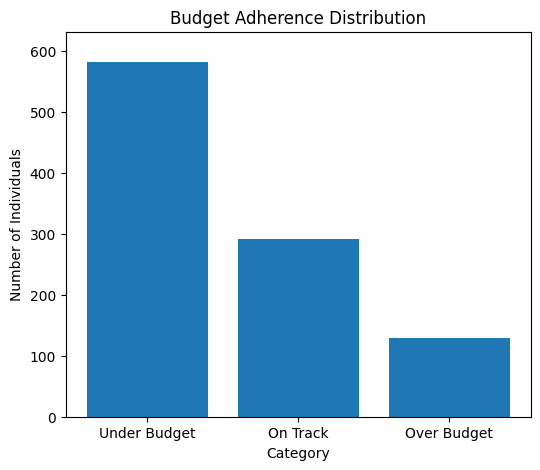

In [667]:
# pertanyaan 1
# visualisasi distribusi kepatuhan budget menentukan nilai tertinggi menentukan nilai tertinggi
max_value = budget_summary['Jumlah'].max()

plt.figure(figsize=(6,5))

plt.bar(
    budget_summary.index,
    budget_summary['Jumlah'],
)

plt.title("Budget Adherence Distribution")
plt.xlabel("Category")
plt.ylabel("Number of Individuals")

plt.ylim(0, budget_summary['Jumlah'].max() + 50)

plt.xticks(rotation=0)

plt.show()

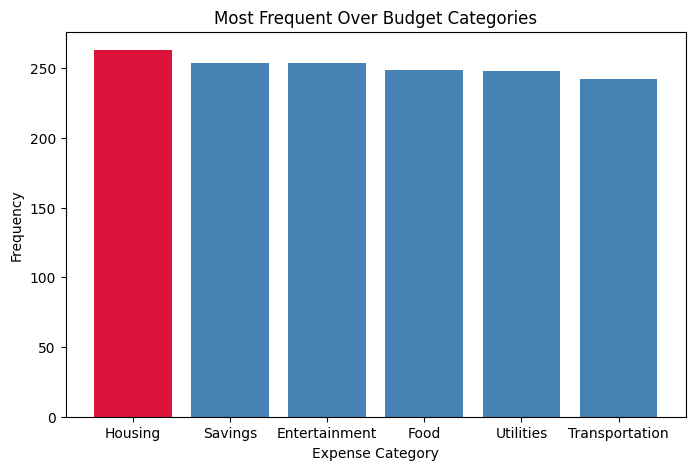

In [668]:
# pertanyaan 2
# membuat diagram batang untuk menampilkan kategori dengan frekuensi over budget tertinggi
max_value = result['OverBudgetCount'].max()

colors = [
    'crimson' if value == max_value else 'steelblue'
    for value in result['OverBudgetCount']
]

plt.figure(figsize=(8,5))

plt.bar(
    result['Category'],
    result['OverBudgetCount'],
    color=colors
)

plt.title("Most Frequent Over Budget Categories")
plt.xlabel("Expense Category")
plt.ylabel("Frequency")

plt.xticks(rotation=0)

plt.show()

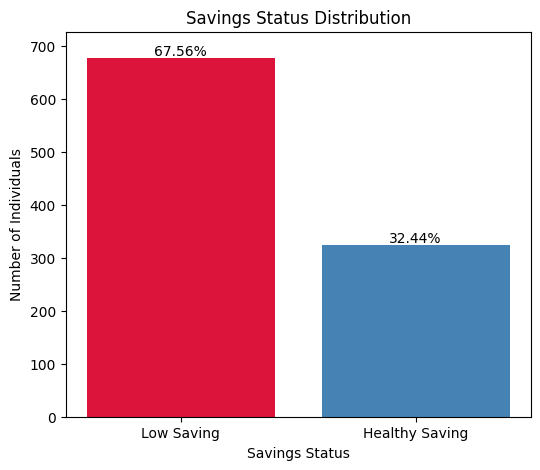

In [669]:
# pertanyaan 3
# membuat visualisasi persentase status tabungan individu dalam bentuk diagram batang
max_value = summary['Jumlah Individu'].max()

colors = [
    'crimson' if value == max_value else 'steelblue'
    for value in summary['Jumlah Individu']
]

plt.figure(figsize=(6,5))

plt.bar(
    summary.index,
    summary['Jumlah Individu'],
    color=colors
)

for i, value in enumerate(summary['Jumlah Individu']):
    plt.text(
        i,
        value + 5,
        summary['Persentase'].iloc[i],
        ha='center'
    )

plt.title("Savings Status Distribution")
plt.xlabel("Savings Status")
plt.ylabel("Number of Individuals")

plt.ylim(0, summary['Jumlah Individu'].max() + 50)

plt.show()

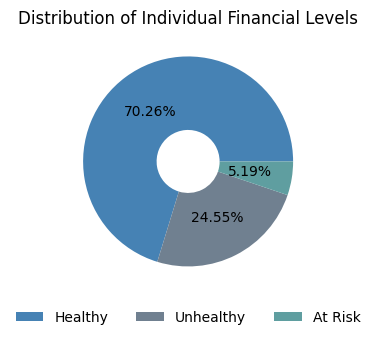

In [670]:
# membuat visualisasi distribusi tingkat kondisi keuangan individu dalam bentuk diagram pie
max_value = level_summary['Persentase'].max()

colors = [
    'steelblue',
    'slategray',
    'cadetblue'
]

# 1. Sesuaikan figsize menjadi (5, 3.5) seperti di Streamlit
fig, ax = plt.subplots(figsize=(5, 3.5))

# 2. Atur posisi lingkaran agar membesar ke bawah dan menyisakan ruang untuk judul
ax.set_position([0.1, 0.15, 0.8, 0.75])

# 3. Hilangkan argumen `labels=` agar teks tidak menempel di lingkaran
wedges, texts, autotexts = ax.pie(
    level_summary['Persentase'],
    autopct='%1.2f%%',
    colors=colors,
    wedgeprops={'width': 0.7}
)

# 4. Tambahkan padding pada judul
ax.set_title('Distribution of Individual Financial Levels', pad=5)

# 5. Tambahkan legenda di bawah lingkaran (sama persis dengan format Streamlit)
ax.legend(
    wedges,
    level_summary.index,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=3,
    frameon=False
)

plt.show()

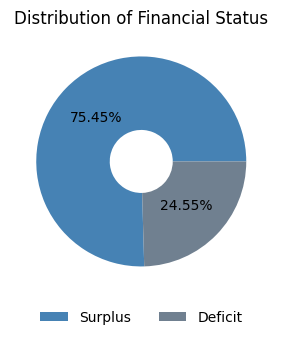

In [671]:
# Membuat visualisasi distribusi status finansial individu dalam bentuk diagram pie
max_val_status = status_summary['Persentase'].max()

# Warna dinamis: steelblue untuk nilai tertinggi, slategray untuk sisanya
colors_status = ['steelblue' if val == max_val_status else 'slategray' for val in status_summary['Persentase']]

# 1. Menyesuaikan figsize menjadi (5, 3.5)
fig, ax = plt.subplots(figsize=(5, 3.5))

# 2. Mengatur posisi area lingkaran agar membesar ke bawah
ax.set_position([0.1, 0.15, 0.8, 0.75])

# 3. Membuat pie chart tanpa label teks di pinggiran (labels dihapus)
wedges, texts, autotexts = ax.pie(
    status_summary['Persentase'],
    autopct='%1.2f%%',
    colors=colors_status,
    wedgeprops={'width': 0.7} # Ketebalan donut chart
)

# 4. Menambahkan judul dengan padding
ax.set_title('Distribution of Financial Status', pad=5)

# 5. Menambahkan legenda di bagian bawah dengan 2 kolom (ncol=2)
ax.legend(
    wedges,
    status_summary.index,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=2,
    frameon=False
)

plt.show()

**Insight :**

1. Mayoritas Individu Patuh Terhadap Anggaran (Budget Adherence)

    Sebagian besar populasi memiliki kontrol pengeluaran yang baik, didominasi oleh kelompok Under Budget dan kelompok On Track yang disiplin, sementara kelompok yang melebihi anggaran (Over Budget) berada di jumlah paling minim.

2. Kategori Tertentu Menjadi Pemicu Utama Kebocoran Dana (Most Frequent Over Budget)
    
    Kategori pengeluaran spesifik yang berwarna merah (crimson) berhasil diidentifikasi sebagai sektor yang paling sering melampaui batas anggaran, menjadikannya prioritas utama untuk penyesuaian strategi atau fitur peringatan (alerting).

3. Mayoritas Individu Memiliki Kebiasaan Menabung yang Rendah (Savings Status)
    
    Terjadi ketimpangan besar dalam perilaku menabung, di mana sebanyak 67.56% individu masuk dalam kategori Low Saving dan hanya 32.44% yang berhasil menyisihkan tabungan secara ideal (Healthy Saving).

4. Kesehatan Finansial Didominasi Kategori Aman (Financial Levels)
    
    Sebanyak 70.26% individu berhasil mencapai tingkat keuangan yang Healthy, namun terdapat hampir 30% populasi gabungan Unhealthy dan At Risk yang diduga terdampak oleh rendahnya alokasi tabungan mereka.

5. Kondisi Saldo Keseluruhan Lebih Banyak Mengalami Surplus (Financial Status)
    
    Sebagian besar pengguna berhasil mempertahankan status finansial positif (Surplus) di mana pendapatan lebih besar dari total pengeluaran, sedangkan sebagian kecil sisanya berada dalam kondisi Deficit yang membutuhkan evaluasi anggaran.

## A/B Testing

In [672]:
# Definisikan Hipotesis
print("H0: Tidak ada perbedaan rata-rata pengeluaran hiburan antara kelompok Surplus dan Deficit.")
print("H1: Terdapat perbedaan rata-rata pengeluaran hiburan yang signifikan antara kelompok Surplus dan Deficit.\n")

# Pisahkan data menjadi dua kelompok
group_surplus = df[df['FinancialStatus'] == 'Surplus']['EntertainmentExpense']
group_deficit = df[df['FinancialStatus'] == 'Deficit']['EntertainmentExpense']

# Lakukan T-Test
t_stat, p_value = stats.ttest_ind(group_surplus, group_deficit, equal_var=False, nan_policy='omit')

# Tampilkan Hasil Statistik
print(f"Rata-rata Entertainment Surplus : {group_surplus.mean():.2f}")
print(f"Rata-rata Entertainment Deficit : {group_deficit.mean():.2f}")
print("-" * 30)
print(f"T-Statistic : {t_stat:.4f}")
print(f"P-Value     : {p_value:.4f}")

# Buat Kesimpulan Otomatis (Tingkat Kepercayaan 95%)
alpha = 0.05
print("\n--- KESIMPULAN ---")
if p_value < alpha:
    print("Kita Menolak H0.")
    print("Insight: Terdapat perbedaan yang SIGNIFIKAN secara statistik pada pengeluaran hiburan antara individu Surplus dan Deficit.")
else:
    print("Kita Gagal Menolak H0.")
    print("Insight: TIDAK ADA perbedaan yang signifikan pada pengeluaran hiburan antara individu Surplus dan Deficit.")

H0: Tidak ada perbedaan rata-rata pengeluaran hiburan antara kelompok Surplus dan Deficit.
H1: Terdapat perbedaan rata-rata pengeluaran hiburan yang signifikan antara kelompok Surplus dan Deficit.

Rata-rata Entertainment Surplus : 1975.36
Rata-rata Entertainment Deficit : 2083.19
------------------------------
T-Statistic : -3.2638
P-Value     : 0.0012

--- KESIMPULAN ---
Kita Menolak H0.
Insight: Terdapat perbedaan yang SIGNIFIKAN secara statistik pada pengeluaran hiburan antara individu Surplus dan Deficit.


/tmp/ipykernel_2075/3404646187.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax_ab1 = sns.barplot(


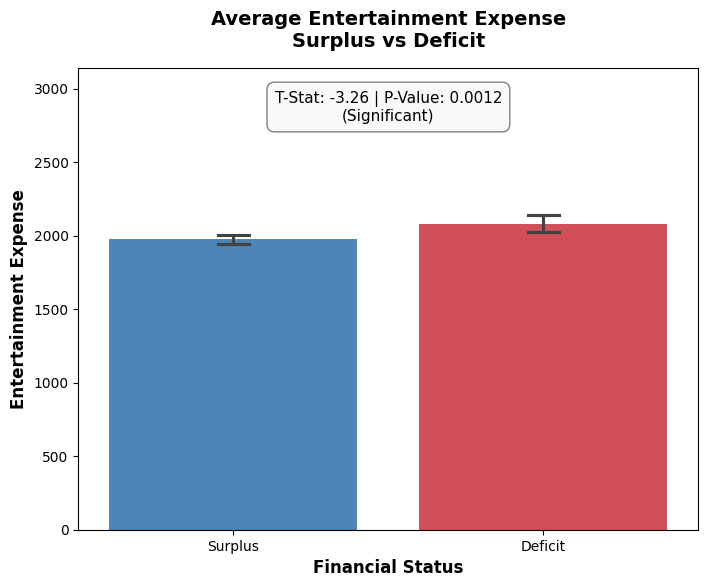

In [673]:
# Filter data khusus untuk Surplus dan Deficit
df_ab1 = df[df['FinancialStatus'].isin(['Surplus', 'Deficit'])]

plt.figure(figsize=(8, 6))

# Membuat Barplot
ax_ab1 = sns.barplot(
    x='FinancialStatus',
    y='EntertainmentExpense',
    data=df_ab1,
    palette={'Surplus': '#3a86c8', 'Deficit': '#e63946'},
    capsize=0.1,
    errorbar='ci'
)

# Kustomisasi Judul dan Label (Translasi ke Bahasa Inggris)
plt.title("Average Entertainment Expense\nSurplus vs Deficit", pad=15, fontweight='bold', fontsize=14)
plt.xlabel("Financial Status", fontweight='bold', fontsize=12)
plt.ylabel("Entertainment Expense", fontweight='bold', fontsize=12)

# --- SOLUSI RUANG KOSONG ---
# Mengambil batas atas tertinggi lalu menambah area kosong 40% di atasnya
current_max_y = ax_ab1.get_ylim()[1]
ax_ab1.set_ylim(0, current_max_y * 1.4)

# Menambahkan Kotak Anotasi Kesimpulan Statistik (Translasi ke Bahasa Inggris)
# Catatan: Variabel t_stat dan p_value disesuaikan dengan variabel di IPYNB kamu
sig_text1 = f"T-Stat: {t_stat:.2f} | P-Value: {p_value:.4f}\n({'Significant' if p_value < 0.05 else 'Not Significant'})"

# Menggunakan transform=ax_ab1.transAxes agar posisi teks relatif terhadap kanvas
plt.text(
    0.5, 0.95,
    sig_text1,
    transform=ax_ab1.transAxes,
    ha='center', va='top', fontsize=11, color='black',
    bbox=dict(facecolor='#f8f9fa', edgecolor='gray', boxstyle='round,pad=0.5')
)

plt.show()

In [674]:
# Definisikan Hipotesis
print("H0: Tidak ada hubungan yang signifikan antara Status Tabungan dan Jumlah Kategori Kebocoran (Over Budget).")
print("H1: Terdapat hubungan yang signifikan antara Status Tabungan dan Jumlah Kategori Kebocoran.\n")

# Mengelompokkan OverBudgetCount menjadi kategori agar cocok untuk Chi-Square
def kelompokkan_kebocoran(x):
    if x == 0:
        return '0 Leaks'
    elif x <= 2:
        return '1-2 Leaks'
    else:
        return '>2 Leaks'

df['KebocoranCategory'] = df['OverBudgetCount'].apply(kelompokkan_kebocoran)

# Memastikan kita hanya mengambil data yang relevan
df_filtered = df[df['SavingsStatus'].isin(['Healthy Saving', 'Low Saving'])]

# Membuat Tabel Kontingensi (Cross Tabulation)
contingency_table = pd.crosstab(df_filtered['SavingsStatus'], df_filtered['KebocoranCategory'])

print("--- Tabel Kontingensi (Jumlah Individu) ---")
print(contingency_table)
print("\n" + "-" * 40)

# Melakukan Uji Chi-Square
chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)

# Tampilkan Hasil Statistik
print(f"Chi-Square Statistic : {chi2_stat:.4f}")
print(f"P-Value              : {p_value:.4f}")
print(f"Degrees of Freedom   : {dof}")

# Buat Kesimpulan Otomatis (Tingkat Kepercayaan 95%)
alpha = 0.05
print("\n--- KESIMPULAN ---")
if p_value < alpha:
    print("Kita Menolak H0.")
    print("Insight: Terdapat hubungan yang SIGNIFIKAN secara statistik antara status tabungan seseorang dengan seberapa sering anggaran mereka jebol.")
else:
    print("Kita Gagal Menolak H0.")
    print("Insight: TIDAK ADA hubungan yang signifikan antara status tabungan dan jumlah kebocoran anggaran.")

H0: Tidak ada hubungan yang signifikan antara Status Tabungan dan Jumlah Kategori Kebocoran (Over Budget).
H1: Terdapat hubungan yang signifikan antara Status Tabungan dan Jumlah Kategori Kebocoran.

--- Tabel Kontingensi (Jumlah Individu) ---
KebocoranCategory  0 Leaks  1-2 Leaks  >2 Leaks
SavingsStatus                                  
Healthy Saving         118         29       178
Low Saving             531         84        62

----------------------------------------
Chi-Square Statistic : 253.2519
P-Value              : 0.0000
Degrees of Freedom   : 2

--- KESIMPULAN ---
Kita Menolak H0.
Insight: Terdapat hubungan yang SIGNIFIKAN secara statistik antara status tabungan seseorang dengan seberapa sering anggaran mereka jebol.


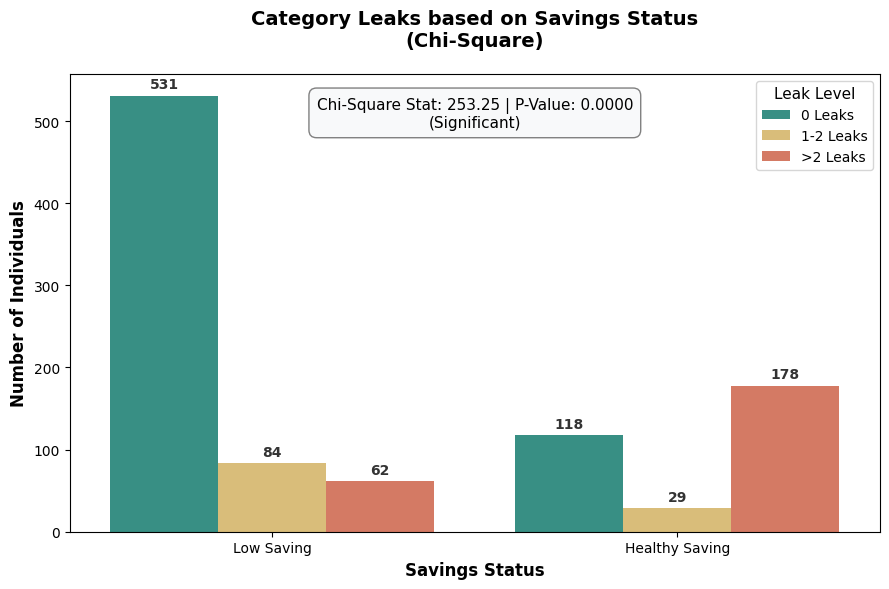

In [675]:
plt.figure(figsize=(9, 6))

# Membuat Grouped Bar Chart menggunakan countplot
# Warna: Hijau (Aman/0), Kuning (Peringatan/1-2), Merah (Bahaya/>2)
ax_ab3 = sns.countplot(
    data=df_filtered,
    x='SavingsStatus',
    hue='KebocoranCategory',
    hue_order=['0 Leaks', '1-2 Leaks', '>2 Leaks'],
    palette=['#2a9d8f', '#e9c46a', '#e76f51']
)

# Menambahkan label angka pasti di atas setiap batang
for container in ax_ab3.containers:
    ax_ab3.bar_label(container, padding=3, fontweight='bold', color='#333333')

# Kustomisasi Judul, Label, dan Legenda
plt.title("Category Leaks based on Savings Status\n(Chi-Square)", pad=20, fontweight='bold', fontsize=14)
plt.xlabel("Savings Status", fontweight='bold', fontsize=12)
plt.ylabel("Number of Individuals", fontweight='bold', fontsize=12)
plt.legend(title="Leak Level", title_fontsize='11', fontsize='10')

# Mencegah sumbu Y memunculkan angka minus
plt.ylim(bottom=0)

# Menambahkan Kotak Anotasi Statistik
significance_text = f"Chi-Square Stat: {chi2_stat:.2f} | P-Value: {p_value:.4f}\n(Significant)"

plt.text(
    0.5, 0.95,
    significance_text,
    transform=ax_ab3.transAxes,
    ha='center', va='top', fontsize=11, color='black',
    bbox=dict(facecolor='#f8f9fa', edgecolor='gray', boxstyle='round,pad=0.5')
)

plt.tight_layout()
plt.show()